# Rural Theater Reviews Analytics

The purpose of this project is to use natural language processing (NLP), sentiment analysis, topic modeling, and theme comparison to answer the question:


#### What factors most influence customer satisfaction at rural performing arts venues?

Additional thinking questions:
- Are visitors discussing the performance itself or the broader tourism experience?
- What operational issues most affect customer ratings?
- Do tourists value different aspects of the experience than local patrons? <br>
<br>
Tools: Python, pandas, numpy, NLTK, matplotlib, seaborn <br>
<br>
Data: The dataset consists of 650+ publicly available reviews from five theaters in a rural, tourism-based market. While the findings may not generalize to large urban performing centers, they provide insight into customer experiences and satisfaction drivers within comparable rural arts organizations.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv("Reviews Scraping - Data.csv")

df.head()

,Reviewer Name,Review Text,Published Date,Stars Given,Review URL,Owner Response Text,Venue name
0,Troy Everett,NaN,2026-02-02T17:58:49.434Z,5,https://www.google.com/maps/contrib/1007492457...,NaN,Door Shakespeare Day Time Office and Gift Shop
1,Zarata Tapsoba,Friendly staff❤️Great show !!❤️,2025-08-13T21:44:29.416Z,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop
2,Luther Snow,Best theater in Door County. Among the best S...,2025-08-08T21:54:25.906Z,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop
3,nancy mcgrath,Absolutely wonderful production! Our family me...,2025-07-29T04:33:19.793Z,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop
4,Jade D,My favorite part of Door County!!!! Absolutely...,2025-07-05T23:51:56.945Z,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop


### Preproduction EDA

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Reviewer Name        655 non-null    str  
 1   Review Text          446 non-null    str  
 2   Published Date       655 non-null    str  
 3   Stars Given          655 non-null    int64
 4   Review URL           655 non-null    str  
 5   Owner Response Text  394 non-null    str  
 6   Venue name           655 non-null    str  
dtypes: int64(1), str(6)
memory usage: 35.9 KB


In [65]:
df.isnull().sum()

Reviewer Name            0
Review Text            209
Published Date           0
Stars Given              0
Review URL               0
Owner Response Text    261
Venue name               0
dtype: int64

Text(0.5, 0, 'Review Stars')

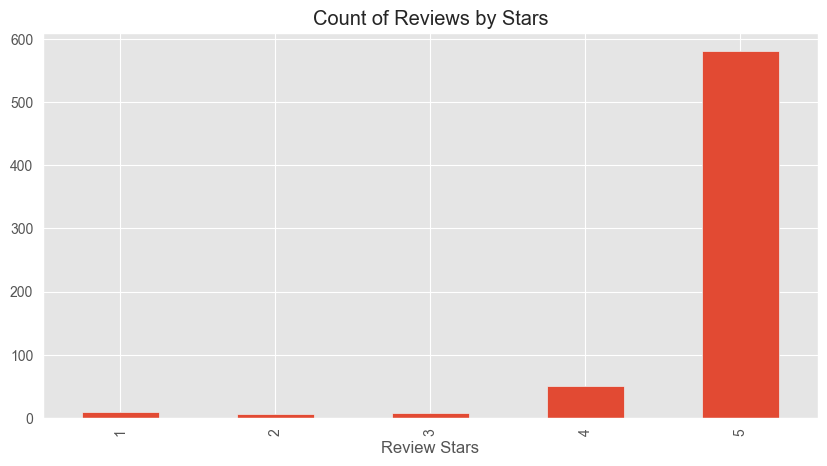

In [66]:
ax = (df['Stars Given'].value_counts().sort_index()
      .plot(kind='bar',
            title='Count of Reviews by Stars',
            figsize=(10,5)))
ax.set_xlabel('Review Stars')

In [67]:
percentages = df['Stars Given'].value_counts(normalize=True).sort_index() * 100
percentages

Stars Given
1     1.526718
2     0.916031
3     1.221374
4     7.786260
5    88.549618
Name: proportion, dtype: float64

Nearly 90% of the reviews are five stars, and over 95% are "positive" (4 or 5 stars). This shows...

In [68]:
df['word_count'] = df['Review Text'].str.split().str.len()
df['word_count'].describe()

count    446.000000
mean      25.764574
std       32.217947
min        1.000000
25%        7.000000
50%       14.000000
75%       32.750000
max      308.000000
Name: word_count, dtype: float64

### Data Cleaning

In [69]:
# feature name normalization
df = df.rename(columns={
    "Reviewer Name": "reviewer_name",
    "Review Text": "review_text",
    "Published Date": "published_date",
    "Stars Given": "stars_given",
    "Review URL": "review_url",
    "Owner Response Text": "owner_response_text",
    "Venue name": "venue_name"
})

# use only reviews with text
df = df.dropna(subset=['review_text'])
df = df.drop_duplicates()
df = df[df['review_text'].str.strip() != ""]

# remove very short reviews
df = df[df['word_count'] >= 3]

df.shape

(420, 8)

In [70]:
import re
# create light cleaned text (for sentiment analysis) and full cleaned text (for topic modeling)
def light_clean_text(txt):
    txt = str(txt)
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def full_clean_text(txt):
    txt = str(txt).lower()
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"[^a-zA-Z\s]", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

df['light_clean_review'] = df['review_text'].apply(light_clean_text)
df['full_clean_review'] = df['review_text'].apply(full_clean_text)

# type conversion to datetime
df['published_date'] = pd.to_datetime(df['published_date']).dt.date

df = df.drop(columns=["reviewer_name"])

df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### NLTK: VADERS Baseline Sentiment Analysis

In [71]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [72]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res[i] = sia.polarity_scores(text)


vaders = pd.DataFrame(res).T
vaders = vaders.merge(df, left_index=True, right_index=True, how='left')
vaders = vaders.rename(columns={'neg' : 'vaders_neg', 'neu' : 'vaders_neu', 'pos' : 'vaders_pos', 'compound' : 'vaders_compound'})
vaders.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,vaders_neg,vaders_neu,vaders_pos,vaders_compound,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,0.000,0.442,0.558,0.5837,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,0.000,0.616,0.384,0.9862,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,0.000,0.698,0.302,0.9540,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,0.000,0.685,0.315,0.8504,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,0.119,0.692,0.189,0.2144,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


In [73]:
from sklearn.metrics import mean_squared_error

vaders["predicted_stars"] = ((vaders['vaders_compound'] + 1) * 2) + 1

rmse_vaders = np.sqrt(mean_squared_error(
    vaders["stars_given"],
    vaders["predicted_stars"]
))

float(rmse_vaders)

0.6658300823569242

### HuggingFace's Roberta Model (Pretrained Transformer model)

In [77]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

example = df.iloc[150]['light_clean_review']
print(sia.polarity_scores(example))
print(example)

{'neg': 0.0, 'neu': 0.496, 'pos': 0.504, 'compound': 0.9458}
Wow. What a special place with special people and a special performance! A visit to Door County will never be complete without a show. Wow!


In [78]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
scores = output.logits[0].detach().numpy()
scores = softmax(scores)

scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}

scores_dict = {
    k: round(float(v), 3)
    for k, v in scores_dict.items()
}

print(scores_dict)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'roberta_neg': 0.002, 'roberta_neu': 0.011, 'roberta_pos': 0.988}


In [79]:
def polarity_scores_roberta(txt):
    """
    function that scores input text on sentiment analysis based on pretrained roberta model
    :param txt: input text
    :return txt_scores_dict: a dictionary of negative, neutral, and positive scores
    """
    encoded_txt = tokenizer(txt, return_tensors='pt')
    txt_output = model(**encoded_txt)
    txt_scores = txt_output.logits[0].detach().numpy()
    txt_scores = softmax(txt_scores)
    txt_scores_dict = {
        'roberta_neg' : txt_scores[0],
        'roberta_neu' : txt_scores[1],
        'roberta_pos' : txt_scores[2]
    }
    return txt_scores_dict


res2 = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res2[i] = polarity_scores_roberta(text)


roberta = pd.DataFrame(res2).T
roberta = roberta.merge(df, left_index=True, right_index=True, how='left')
roberta['roberta_compound'] = roberta['roberta_pos'] - roberta['roberta_neg']
roberta.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,roberta_neg,roberta_neu,roberta_pos,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,roberta_compound
1,0.001475,0.008463,0.990062,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.988587
2,0.001849,0.013335,0.984815,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.982966
3,0.001277,0.007027,0.991696,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.990419
4,0.002348,0.006077,0.991575,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.989227
6,0.400849,0.337175,0.261975,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,-0.138874


In [80]:
roberta["predicted_stars"] = ((roberta['roberta_compound'] + 1) * 2) + 1

rmse_roberta = np.sqrt(mean_squared_error(
    roberta["stars_given"],
    roberta["predicted_stars"]
))

print(float(rmse_vaders))
print(float(rmse_roberta))

0.6658300823569242
0.4174678332106493


The Roberta model performs better than the VADERS model, most likely due to the incredible amount of pretraining that is done beforehand and the complexity of the model.

In [81]:
sentiment_df = df.copy()

sentiment_df = sentiment_df.merge(
    vaders[["vaders_neg", "vaders_neu", "vaders_pos", "vaders_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df = sentiment_df.merge(
    roberta[["roberta_neg", "roberta_neu", "roberta_pos", "roberta_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df["vaders_predicted_stars"] = (
    (sentiment_df["vaders_compound"] + 1) * 2
) + 1

sentiment_df["roberta_predicted_stars"] = round((
    (sentiment_df["roberta_compound"] + 1) * 2
) + 1)

sentiment_df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,vaders_neg,vaders_neu,vaders_pos,vaders_compound,roberta_neg,roberta_neu,roberta_pos,roberta_compound,vaders_predicted_stars,roberta_predicted_stars
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.000,0.442,0.558,0.5837,0.001475,0.008463,0.990062,0.988587,4.1674,5.0
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.000,0.616,0.384,0.9862,0.001849,0.013335,0.984815,0.982966,4.9724,5.0
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.000,0.698,0.302,0.9540,0.001277,0.007027,0.991696,0.990419,4.9080,5.0
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.000,0.685,0.315,0.8504,0.002348,0.006077,0.991575,0.989227,4.7008,5.0
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,0.119,0.692,0.189,0.2144,0.400849,0.337175,0.261975,-0.138874,3.4288,3.0


Text(0.5, 1.0, 'VADERS Compound Score by Star Reviews')

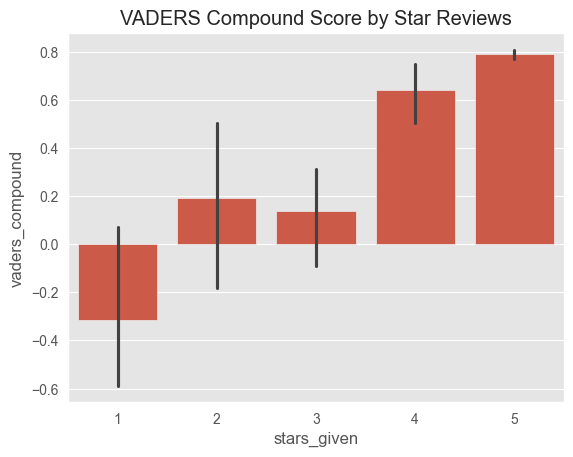

In [82]:
ax = sns.barplot(data=vaders, x="stars_given", y="vaders_compound")
ax.set_title("VADERS Compound Score by Star Reviews")

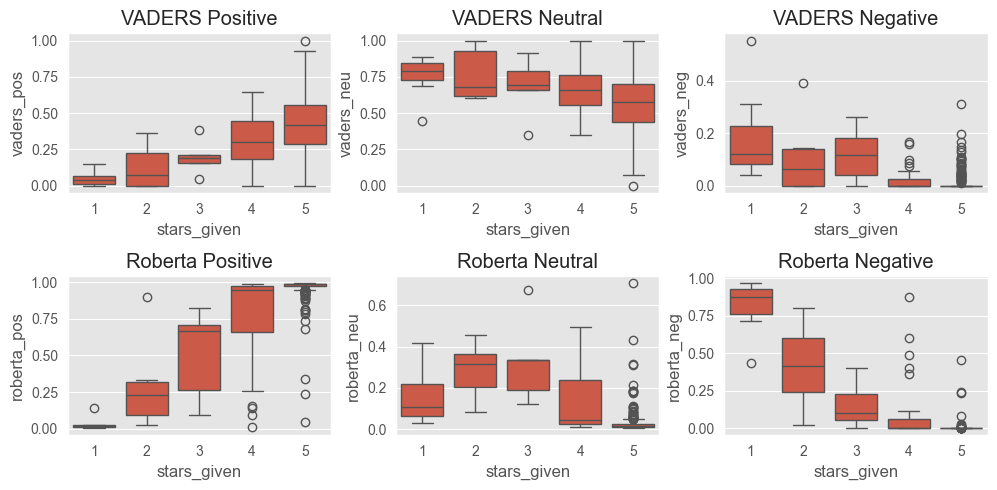

In [87]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_pos", ax=axs[0, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neu", ax=axs[0, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neg", ax=axs[0, 2])
axs[0, 0].set_title("VADERS Positive")
axs[0, 1].set_title("VADERS Neutral")
axs[0, 2].set_title("VADERS Negative")
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_pos", ax=axs[1, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neu", ax=axs[1, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neg", ax=axs[1, 2])
axs[1, 0].set_title("Roberta Positive")
axs[1, 1].set_title("Roberta Neutral")
axs[1, 2].set_title("Roberta Negative")
plt.tight_layout()
plt.show()

<Axes: xlabel='stars_given', ylabel='roberta_compound'>

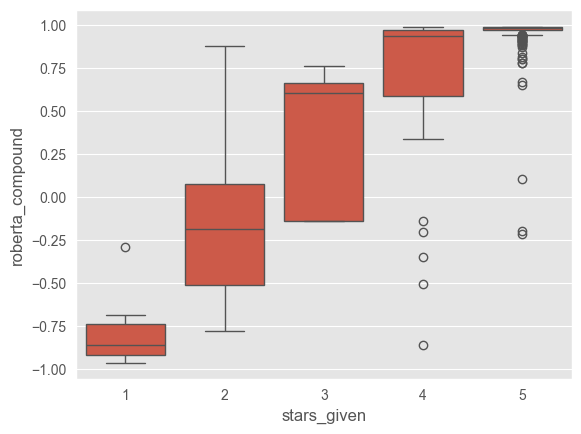

In [88]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="roberta_compound"
)

<Axes: xlabel='stars_given', ylabel='vaders_compound'>

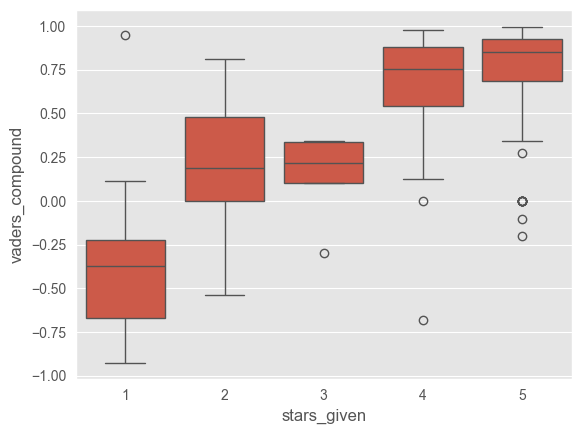

In [89]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="vaders_compound"
)

Both sentiment models demonstrated a relationship between sentiment scores and customer ratings. However, the RoBERTa transformer model appears much more discriminative, creating greater separation between rating categories than VADER. Positive sentiment scores increased consistently from one-star to five-star reviews, while negative sentiment scores decreased. In contrast, VADER classified a large proportion of review text as neutral regardless of rating level, most likely due to the limitations of lexicon-based sentiment analysis approaches. These findings are consistent with the lower RMSE observed for RoBERTa and suggest that contextual transformer-based models capture review sentiment more effectively than lexicon-based approaches.

The most interesting find is the variance in RoBERTa's two-star reviews, which appear very spread in their sentiment intensity. This may suggest that many two-star reviews contain positive language, but the review is dominated by one operational issue.